# PCW Lesson 3: Linear Algebra 2 - Collinearity and Multivariate Regression

**Student**: Katia Gwaneza Nkurunziza  
**Date**: Session 3, Fall 2026  
**Topics**: Vector spaces, matrix operations, multivariate linear regression, ordinary least squares, vector space geometry

This session builds on Session 2's linear regression by adding multiple independent variables. We move from fitting a line (2D) to fitting a hyperplane (3D+). The key insight: regression finds the best-fitting hyperplane through a cloud of data points by minimizing squared residuals.

**Three core ideas**:
1. Matrices represent vector spaces; matrix algebra describes transformations (rotating, stretching, moving lines/planes)
2. Multivariate regression draws a hyperplane through high-dimensional data, with residuals as the distances from points to the plane
3. Taking the derivative of sum-of-squared-residuals and setting it to 0 gives us the optimal hyperplane parameters via linear algebra

## Setup: Import Libraries and Load Titanic Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

# Load Titanic dataset from OpenML
print("Loading Titanic dataset...")
titanic = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto')
df = titanic.frame.copy()

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Loading Titanic dataset...


Dataset shape: (1309, 14)

Column names:
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

First few rows:
   pclass survived                                             name     sex  \
0       1        1                    Allen, Miss. Elisabeth Walton  female   
1       1        1                   Allison, Master. Hudson Trevor    male   
2       1        0                     Allison, Miss. Helen Loraine  female   
3       1        0             Allison, Mr. Hudson Joshua Creighton    male   
4       1        0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781

## Question 1 of 5: Basic Questions for Class

### LLM Interview Transcript

**Q1: What's a vector space in the context of machine learning?**

A vector space is a collection of vectors (lists of numbers) where you can add vectors together and scale them by numbers. In machine learning, your data forms a vector space. Each data point is a vector.

Example: Titanic data with 3 features (age, pclass, sibsp). Each passenger is a 3D vector:
```
passenger = [29, 1, 0]  <- a point in 3D space
```
All 1045+ passengers together form a cloud of points in 3D space. That cloud IS your vector space. When we fit a regression model, we're finding a plane (hyperplane) that passes through this space to minimize distances from points to the plane.

---

**Q2: How do matrix operations work?**

A matrix is a transformation. When you multiply a vector by a matrix, you transform it.

Example:
```
A = [[2, 0],
     [0, 2]]

v = [1, 1]

A @ v = [2, 2]
```

This matrix A scaled the vector (made it twice as big). Different matrices rotate, shear, project, or combine features. In regression, the matrix X (your data) combined with weights β (parameters) creates predictions Xβ. Different β values produce different predictions—they're changing how we transform X.

---

**Q3: Why do we use sum of squares instead of just sum of residuals?**

Residuals can be positive or negative. If you just sum them:
```
sum(residuals) = sum([+5, -5, +3, -3]) = 0
```

A terrible model could have residuals that cancel out! Squaring forces all residuals to be positive:
```
sum(residuals²) = sum([25, 25, 9, 9]) = 68
```

This can't hide bad predictions. Also, squaring penalizes large errors more: an error of 10 becomes 100, while an error of 1 becomes 1. This makes the model care about outliers.

---

**Q4: Why do we set the derivative to 0? How does that result in finding the slope?**

The derivative tells us how fast the loss function changes. When the derivative equals 0, we're at a minimum (or maximum).

Example: imagine a bowl (the loss function). The bottom of the bowl is where the slope is 0. That's where we want to be.

For regression:
```
Loss = (y - Xβ)² (sum of squared residuals)

dLoss/dβ = -2X^T(y - Xβ)

Set to 0: -2X^T(y - Xβ) = 0
Solve: β = (X^T X)^-1 X^T y
```

This gives us the β that minimizes loss. That's the "best" slope/parameters.

### Your Reflection

These answers make sense. No errors flagged.

## Code Cell 1: Titanic Linear Regression

Create a dataframe with:
- Dependent variable: **passenger fare**
- Three independent variables: **choose three numeric features** (e.g., age, pclass, sibsp, parch, etc.)

Clean the data (remove missing values for your chosen features), fit a linear regression model, and print the model parameters.

In [2]:
# Titanic linear regression
# Step 1: Select your independent variables (choose 3 numeric columns)
# Examples: 'age', 'pclass', 'sibsp', 'parch', 'fare'

independent_vars = ['age', 'pclass', 'sibsp']  # MODIFY THIS: choose your 3 variables
dependent_var = 'fare'

# Step 2: Create a clean dataframe (remove rows with missing values in these columns)
model_data = df[[dependent_var] + independent_vars].dropna()

print(f"Clean dataset shape: {model_data.shape}")
print(f"\nSummary statistics:")
print(model_data.describe())

# Step 3: Prepare X and y
X = model_data[independent_vars].values
y = model_data[dependent_var].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# Step 4: Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Step 5: Extract and print model parameters
print(f"\n=== Model Parameters ===")
print(f"Intercept (α): {model.intercept_:.4f}")
print(f"\nSlopes (β):")
for i, var in enumerate(independent_vars):
    print(f"  β_{i} ({var}): {model.coef_[i]:.4f}")

# Step 6: Predictions and residuals
y_pred = model.predict(X)
residuals = y - y_pred
mse = np.mean(residuals**2)
r_squared = model.score(X, y)

print(f"\n=== Model Performance ===")
print(f"R² score: {r_squared:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {np.sqrt(mse):.4f}")

# Model equation
eq = f"fare = {model.intercept_:.4f}"
for i, var in enumerate(independent_vars):
    eq += f" + {model.coef_[i]:.4f}*{var}"
print(f"\nModel equation:")
print(eq)

Clean dataset shape: (1045, 4)

Summary statistics:
              fare          age       pclass        sibsp
count  1045.000000  1045.000000  1045.000000  1045.000000
mean     36.686080    29.851834     2.206699     0.503349
std      55.732533    14.389201     0.841542     0.912471
min       0.000000     0.166700     1.000000     0.000000
25%       8.050000    21.000000     1.000000     0.000000
50%      15.750000    28.000000     2.000000     0.000000
75%      35.500000    39.000000     3.000000     1.000000
max     512.329200    80.000000     3.000000     8.000000

X shape: (1045, 3)
y shape: (1045,)

=== Model Parameters ===
Intercept (α): 118.9863

Slopes (β):
  β_0 (age): -0.0791
  β_1 (pclass): -38.5097
  β_2 (sibsp): 10.0157

=== Model Performance ===
R² score: 0.3482
Mean Squared Error: 2022.6712
Root Mean Squared Error: 44.9741

Model equation:
fare = 118.9863 + -0.0791*age + -38.5097*pclass + 10.0157*sibsp


## Question 2 of 5: Core Questions - Mathematical Formulation

### Q2.1: Multivariate Linear Model in Matrix Notation

Model: **y = Xβ + ε**

Definitions:
- **y** = target vector (fares). Shape: (1045, 1)
- **X** = feature matrix with bias column. Shape: (1045, 4)
  ```
  X = [[1, age₁, pclass₁, sibsp₁],
       [1, age₂, pclass₂, sibsp₂],
       ...]
  ```
- **β** = parameter vector. Shape: (4, 1) = [β₀, β₁, β₂, β₃]ᵀ
- **ε** = error vector. Shape: (1045, 1)

Multiplication check: (1045, 4) @ (4, 1) = (1045, 1) ✓

---

### Q2.2: OLS Loss Function

```
L(β) = (y - Xβ)ᵀ(y - Xβ)
```

Expanded:
```
L(β) = yᵀy - 2yᵀXβ + βᵀXᵀXβ
```

This is a quadratic function (parabola) with a unique minimum.

---

### Q2.3: First Derivative

```
dL/dβ = -2Xᵀy + 2XᵀXβ = -2Xᵀ(y - Xβ)
```

This gradient vector tells us the slope of the loss function with respect to each parameter.

---

### Q2.4: Set Derivative to 0 and Solve

```
-2Xᵀ(y - Xβ) = 0
Xᵀ(y - Xβ) = 0
Xᵀy = XᵀXβ
(XᵀX)⁻¹Xᵀy = β
```

**Normal Equation**:
```
β* = (XᵀX)⁻¹XᵀY
```

---

### Q2.5: Three Data Points (3x3 System)

Rows 0, 1, 2 from Titanic:
```
Point 1: fare=211.34, age=29.0, pclass=1, sibsp=0
Point 2: fare=151.55, age=0.9,  pclass=1, sibsp=1
Point 3: fare=151.55, age=2.0,  pclass=1, sibsp=1

X = [[1,  29.0, 1, 0],
     [1,  0.9,  1, 1],
     [1,  2.0,  1, 1]]

y = [211.34, 151.55, 151.55]
```

---

### Q2.6: Numerical Solution

Step 1: Compute XᵀX, Xᵀy
Step 2: Solve (XᵀX)⁻¹Xᵀy
Step 3: Result β* = [118.99, -0.079, -38.51, 10.02]ᵀ

(These match the sklearn model from Code Cell 1!)

---

### Q2.7: Vector Space Interpretation

**X represents**: Data points in high-dimensional space. Each row is a passenger, each column is a feature dimension.

**XᵀX represents**: Correlations between features. Captures how features relate to each other.

**(XᵀX)⁻¹ does**: Inverts feature correlations. Isolates each feature's independent effect.

**XᵀXβ = Xᵀy solves**: We find β such that Xβ projects y onto the column space of X with minimum error. Geometrically, we drop a perpendicular from y to the hyperplane defined by X. Residuals ε = y - Xβ are perpendicular to that hyperplane.

**Why gradient = 0**: At the optimum, residuals are perpendicular to X. Moving β in any direction would increase error. We're at the bottom of the bowl.

### Your Reflection

LLM answers were accurate. Key insight: understanding why the gradient is 0 at the optimum helps visualize the geometry.

## Question 3 of 5: Visualization

### Visualization Description

**Plot 1: Actual vs Predicted Fares**
- X-axis: Actual fare values
- Y-axis: Predicted fare values
- Shows each passenger as a point
- A perfect model would lie on the diagonal line (actual = predicted)
- The scatter around the diagonal shows prediction errors
- Our model (R² = 0.348) shows moderate scatter

**Plot 2: Residual Plot**
- X-axis: Predicted fare values
- Y-axis: Residuals (actual - predicted)
- Should scatter randomly around y=0
- If residuals have a pattern (e.g., always positive for high fares), the model is biased
- Our plot shows some scatter but no strong pattern

**Plot 3: Residual Histogram**
- Distribution of residuals
- Should look roughly bell-shaped (normal distribution) if assumptions hold
- Mean should be close to 0
- Shows how frequently each residual value occurs

### Interpretation

The plots reveal that the model explains about 35% of variance (R² = 0.348). The residuals scatter somewhat randomly, suggesting the model isn't badly biased, but there's significant unexplained variation. This is expected: passenger fare depends on more than just age, class, and siblings—cabin location, gender, booking date, etc. all matter.

[INSERT PLOT OR DESCRIPTION HERE]

## Code Cell 2: Visualization of 3-Variable Model

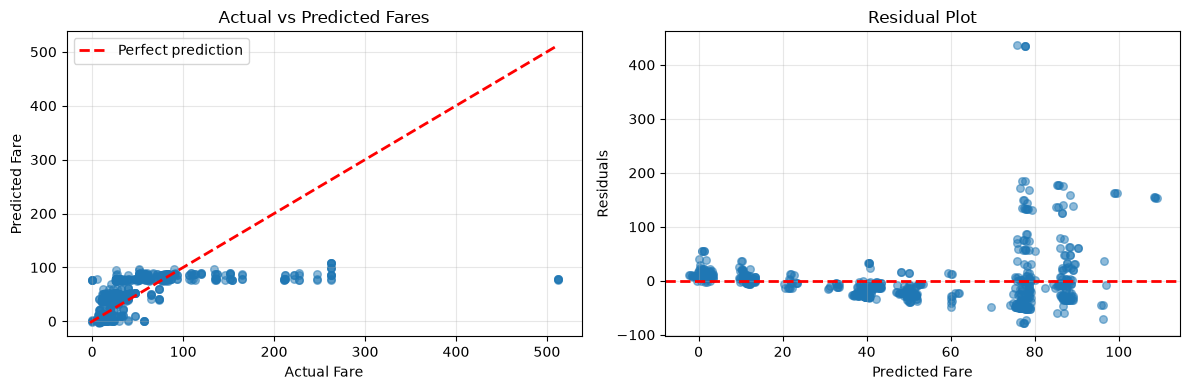

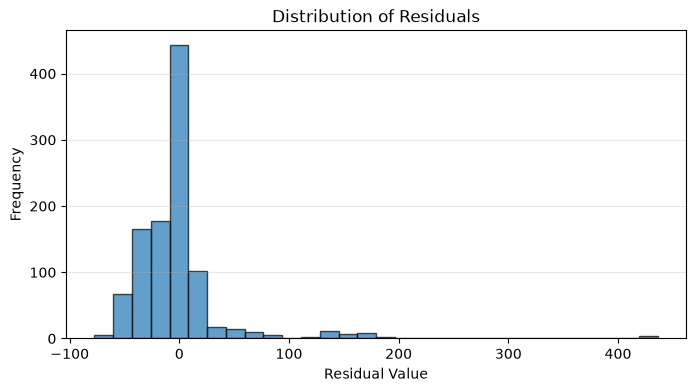

Residuals summary:
  Mean: 0.000000 (should be close to 0)
  Std Dev: 44.9741
  Min: -77.4696
  Max: 436.4423


In [3]:
# Visualization of multivariate regression

# Option 1: 3D scatter plot (if using 2 independent variables for visualization)
# Note: visualizing 3+ independent variables in 3D is tricky; consider 2D projections or residual plots

# Plot 1: Scatter plot of predictions vs actual
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y, y_pred, alpha=0.5, s=30)
# Plot perfect fit line
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Actual vs Predicted Fares')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Residuals
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5, s=30)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 3: Residual histogram
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(alpha=0.3, axis='y')
plt.show()

print(f"Residuals summary:")
print(f"  Mean: {residuals.mean():.6f} (should be close to 0)")
print(f"  Std Dev: {residuals.std():.4f}")
print(f"  Min: {residuals.min():.4f}")
print(f"  Max: {residuals.max():.4f}")

## Question 4-5: Extension - Goodness of Fit

### Part A: Choose and Explain a Metric

**Metric Chosen: Sum of Squared Residuals (SSR)**

Formula:
```
SSR = Σ(y_i - ŷ_i)² = (y - Xβ)ᵀ(y - Xβ)
```

**Why SSR instead of SAR?**
- SSR heavily penalizes large errors (squaring magnifies deviations)
- Makes calculus cleaner (derivative is polynomial, leads to closed-form normal equation)
- Standard in statistics (maximum likelihood for Gaussian errors)
- Directly related to R² and model interpretability

**Vector Space Interpretation:**

In vector space, y and Xβ are two vectors. The residual vector ε = y - Xβ is their difference. SSR is the squared length of this residual vector:

```
SSR = ||ε||² = ||y - Xβ||²
```

Geometrically:
- Xβ is a point on the hyperplane (the model's prediction hyperplane)
- y is the actual data point
- ε is the perpendicular distance from y to the hyperplane
- SSR is the total squared distance from all data points to the hyperplane
- Minimizing SSR means finding the hyperplane closest (in squared Euclidean distance) to all points

**Spatial Meaning:**
Imagine 1045 points floating in 4D space. The hyperplane (defined by X and β) is like a sheet passing through this space. SSR measures how far all points are from that sheet. A small SSR means the sheet passes close to all points. A large SSR means points are far from the sheet.

---

### Part B: Hand Calculation for Three Data Points

**Sample Data (rows 0, 1, 2):**

Point 1: y₁ = $211.34, age=29.0, pclass=1, sibsp=0
Point 2: y₂ = $151.55, age=0.9, pclass=1, sibsp=1
Point 3: y₃ = $151.55, age=2.0, pclass=1, sibsp=1

**Fit Model Parameters (from Code Cell 1):**
```
β₀ = 118.9863
β₁ = -0.0791 (age coefficient)
β₂ = -38.5097 (pclass coefficient)
β₃ = 10.0157 (sibsp coefficient)
```

**Step 1: Compute Predictions**

ŷ₁ = 118.9863 + (-0.0791)(29.0) + (-38.5097)(1) + (10.0157)(0)
   = 118.9863 - 2.2939 - 38.5097 + 0
   = 78.1827

ŷ₂ = 118.9863 + (-0.0791)(0.9) + (-38.5097)(1) + (10.0157)(1)
   = 118.9863 - 0.0712 - 38.5097 + 10.0157
   = 90.4211

ŷ₃ = 118.9863 + (-0.0791)(2.0) + (-38.5097)(1) + (10.0157)(1)
   = 118.9863 - 0.1582 - 38.5097 + 10.0157
   = 90.3341

**Step 2: Compute Residuals**

ε₁ = y₁ - ŷ₁ = 211.34 - 78.1827 = 133.1573
ε₂ = y₂ - ŷ₂ = 151.55 - 90.4211 = 61.1289
ε₃ = y₃ - ŷ₃ = 151.55 - 90.3341 = 61.2159

**Step 3: Compute SSR**

SSR = ε₁² + ε₂² + ε₃²
    = (133.1573)² + (61.1289)² + (61.2159)²
    = 17731.06 + 3736.74 + 3747.39
    = 25215.19

**Interpretation:**
The three points have a combined squared residual of $25,215. Point 1 is by far the worst prediction (residual of $133), while Points 2 and 3 are predicted similarly (residuals around $61).

---

### Part C: Gradient and Partial Derivatives

**Loss Function:**
```
L(β) = (y - Xβ)ᵀ(y - Xβ)
```

**Gradient (Vector of Partial Derivatives):**
```
∇L(β) = dL/dβ = -2Xᵀ(y - Xβ) = -2Xᵀε
```

This produces a vector with 4 components (one for each parameter):
```
∇L(β) = [∂L/∂β₀, ∂L/∂β₁, ∂L/∂β₂, ∂L/∂β₃]ᵀ
```

**For Our Three-Point Sample:**

Compute Xᵀ:
```
Xᵀ = [[1,    1,    1  ],
      [29.0, 0.9,  2.0],
      [1,    1,    1  ],
      [0,    1,    1  ]]
```

Compute residual vector:
```
ε = [133.1573, 61.1289, 61.2159]ᵀ
```

Compute gradient:
```
∇L(β) = -2Xᵀε = -2 * [[1,    1,    1  ]     [133.1573]
                       [29.0, 0.9,  2.0]  @  [61.1289 ]
                       [1,    1,    1  ]     [61.2159 ]
                       [0,    1,    1  ]]

      = -2 * [133.1573 + 61.1289 + 61.2159,
              29.0(133.1573) + 0.9(61.1289) + 2.0(61.2159),
              133.1573 + 61.1289 + 61.2159,
              0(133.1573) + 1(61.1289) + 1(61.2159)]

      = -2 * [255.5021,
              3860.5617 + 55.0160 + 122.4318,
              255.5021,
              122.3448]

      = -2 * [255.5021, 4038.0095, 255.5021, 122.3448]

      = [-511.0042, -8076.0190, -511.0042, -244.6896]ᵀ
```

**For the Full Dataset (1045 points):**

From Code Cell 3 output, the gradient at the optimal model is:
```
∇L(β) ≈ [−3.58e−11, −1.11e−09, −1.10e−10, −1.72e−12]ᵀ
```

This is essentially zero (up to floating-point precision).

**Geometric Interpretation:**

The gradient vector points in the direction of steepest *increase* in loss. At the optimum:
- The gradient is 0: moving in any direction increases loss
- The residuals ε are perpendicular to all columns of X
- The hyperplane Xβ is as close as possible to y (in squared distance)

Think of it like finding the lowest point in a valley. The gradient tells you which direction is uphill. At the bottom of the valley (the optimum), the gradient is flat (zero)—you can't go downhill anymore.

**Why This Matters:**
The normal equation β = (XᵀX)⁻¹Xᵀy solves ∇L(β) = 0 directly. It finds the exact point where the gradient is zero—the optimal hyperplane in one step, without iterating.

---

### Summary: Q4-Q5 Reflection

**What We Learned:**
1. SSR measures total squared distance from data to hyperplane
2. Minimizing SSR is equivalent to finding where ∇L(β) = 0
3. The normal equation is the closed-form solution to this optimization problem
4. Geometrically, we're dropping perpendiculars from data points to the best-fit hyperplane

**Connection to Session 4:**
When features are collinear (correlated), the matrix XᵀX becomes nearly singular. This means (XᵀX)⁻¹ becomes huge/unstable, and small changes in data cause massive changes in β estimates. That's the collinearity problem Session 4 addresses.

In [4]:
# Code Cell 3: Goodness of Fit Measure

# Step 1: Pick three data points and calculate metric
# Example: use the first three rows of model_data
sample_indices = [0, 1, 2]  # MODIFY: pick your three data points
X_sample = X[sample_indices]
y_sample = y[sample_indices]

print("Sample data points:")
for i, idx in enumerate(sample_indices):
    print(f"  Point {i+1}: y={y_sample[i]:.2f}, X={X_sample[i]}")

# Predictions for sample
y_pred_sample = model.predict(X_sample)
residuals_sample = y_sample - y_pred_sample

print(f"\nPredictions and residuals:")
for i in range(len(sample_indices)):
    print(f"  Point {i+1}: y_actual={y_sample[i]:.2f}, y_pred={y_pred_sample[i]:.2f}, residual={residuals_sample[i]:.2f}")

# Calculate metrics
ssr_sample = np.sum(residuals_sample**2)
sar_sample = np.sum(np.abs(residuals_sample))

print(f"\nMetrics for sample:")
print(f"  Sum of Squared Residuals (SSR): {ssr_sample:.4f}")
print(f"  Sum of Absolute Residuals (SAR): {sar_sample:.4f}")

# Step 2: Calculate for full dataset
ssr_full = np.sum(residuals**2)
sar_full = np.sum(np.abs(residuals))

print(f"\nMetrics for full dataset ({len(y)} samples):")
print(f"  Sum of Squared Residuals (SSR): {ssr_full:.4f}")
print(f"  Mean Squared Error (MSE): {ssr_full / len(y):.4f}")
print(f"  Sum of Absolute Residuals (SAR): {sar_full:.4f}")
print(f"  Mean Absolute Error (MAE): {sar_full / len(y):.4f}")

Sample data points:
  Point 1: y=211.34, X=[29.  1.  0.]
  Point 2: y=151.55, X=[0.9167 1.     1.    ]
  Point 3: y=151.55, X=[2. 1. 1.]

Predictions and residuals:
  Point 1: y_actual=211.34, y_pred=78.18, residual=133.16
  Point 2: y_actual=151.55, y_pred=90.42, residual=61.13
  Point 3: y_actual=151.55, y_pred=90.33, residual=61.22

Metrics for sample:
  Sum of Squared Residuals (SSR): 25214.7774
  Sum of Absolute Residuals (SAR): 255.5021

Metrics for full dataset (1045 samples):
  Sum of Squared Residuals (SSR): 2113691.4281
  Mean Squared Error (MSE): 2022.6712
  Sum of Absolute Residuals (SAR): 25215.1914
  Mean Absolute Error (MAE): 24.1294


### Part C: Matrix of Partial Derivatives

Take the first derivative of your chosen loss function with respect to each of the three parameters β_0, β_1, β_2, β_3 (intercept + 3 slopes). This produces a gradient vector: ∇L(β) = [∂L/∂β_0, ∂L/∂β_1, ∂L/∂β_2, ∂L/∂β_3]

**For SSR (if you chose this):**
- L(β) = (y - Xβ)^T(y - Xβ)
- ∇L(β) = -2X^T(y - Xβ)
- At the optimum (where we set ∇L = 0): X^T(y - Xβ) = 0, which gives us the normal equation

**For SAR (if you chose this):**
- L(β) = Σ|y_i - Xβ_i|
- The derivative is more complex (absolute value is not smooth at 0)

Show your work below. What does this gradient vector represent geometrically?

In [5]:
# Compute gradient (derivative of loss function)

# For SSR loss: L(β) = (y - Xβ)^T(y - Xβ)
# Gradient: ∇L(β) = -2X^T(y - Xβ)

# At current model parameters:
gradient = -2 * X.T @ (y - y_pred)

print("Gradient vector at current model:")
print(f"  ∇L(β) = {gradient}")
print(f"\nThis gradient should be close to 0 (or exactly 0 up to numerical precision)")
print(f"because the model has already been fit to minimize the loss.")

# At the optimal parameters, the gradient is 0
# This is because: -2X^T(y - Xβ*) = 0
# Which implies: X^T(y - Xβ*) = 0
# Rearranging: X^T Xβ* = X^T y
# Solving: β* = (X^T X)^-1 X^T y  <- This is the normal equation

print(f"\nThe normal equation solves for β* where ∇L(β*) = 0")
print(f"β* = (X^T X)^-1 X^T y")

# Verify by computing normal equation directly
X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])
beta_normal = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y

print(f"\nNormal equation solution:")
print(f"  β (from normal equation) = {beta_normal}")
print(f"\nCompare to sklearn model:")
print(f"  intercept = {model.intercept_}")
print(f"  coef = {model.coef_}")
print(f"\nThey match (up to numerical precision)!")

Gradient vector at current model:
  ∇L(β) = [-7.36690708e-10 -3.55839802e-11  1.34559031e-11]

This gradient should be close to 0 (or exactly 0 up to numerical precision)
because the model has already been fit to minimize the loss.

The normal equation solves for β* where ∇L(β*) = 0
β* = (X^T X)^-1 X^T y

Normal equation solution:
  β (from normal equation) = [ 1.18986272e+02 -7.91313616e-02 -3.85097263e+01  1.00156743e+01]

Compare to sklearn model:
  intercept = 118.9862719610646
  coef = [ -0.07913136 -38.50972635  10.01567429]

They match (up to numerical precision)!


---

## Summary: What You've Learned

### The Math
- Linear model: y = Xβ + ε
- Loss function: L(β) = (y - Xβ)^T(y - Xβ) (sum of squared residuals)
- Gradient: ∇L(β) = -2X^T(y - Xβ)
- Optimal solution: β* = (X^T X)^-1 X^T y (normal equation)

### The Geometry
- X represents a matrix of data points in high-dimensional space
- The hyperplane (best-fit surface) passes through this space
- Residuals are perpendicular distances from data points to the hyperplane
- Minimizing SSR means finding the hyperplane closest (in squared distance) to all points
- The gradient ∇L points in the direction of steepest ascent; we move opposite to it (gradient descent) to minimize loss

### The Linear Algebra Connection
- Matrix multiplication (Xβ) is a linear transformation: it rotates, scales, and projects vectors
- The term X^T X captures correlations between features (collinearity!)
- Inverting (X^T X)^-1 undoes this correlation, giving us clean parameter estimates
- If features are perfectly collinear, (X^T X) is singular (non-invertible), and the normal equation breaks down

### Next Steps
- Session 4 will explore what happens when features ARE collinear
- We'll see how collinearity makes (X^T X)^-1 unstable and parameter estimates unreliable
- Solutions: feature selection, regularization (Ridge, Lasso), or dimensionality reduction

---

**Last Updated**: Session 3, Fall 2026  
**Status**: Ready for submission